# **Financial Data Acquisition & Processing**

**Goal**  
 Download price data for 5 tech stocks and SPY, compute key metrics, and visualize return distributions.

**Stocks**  
AAPL,MSFT, NVDA, META, GOOGL, SPY

**Period**  
2020-01-01 to 2024-12-31

In [1]:
#Import
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as dridspec

#Settings
TICKERS = ['AAPL', 'MSFT', 'NVDA', 'META', 'GOOGL', 'SPY']
START   = '2020-01-01'
END     = '2025-12-31'

### **Download Data**

In [10]:
raw = yf.download(TICKERS, start=START, end=END)

prices = raw['Close']
prices = prices.dropna()

print(f"Shape: {prices.shape}")
print(f"Date range: {prices.index[0].date()} → {prices.index[-1].date()}")

[*********************100%***********************]  6 of 6 completed

Shape: (1507, 6)
Date range: 2020-01-02 → 2025-12-30


### **Daily Returns**  
Daily Return = (Today's Close - Yesterday's Close) / Yesterday's Close

In [11]:
returns = prices.pct_change().dropna()

# check
print("Mean daily return:")
print(returns.mean().round(4))

Mean daily return:
Ticker
AAPL     0.0011
GOOGL    0.0012
META     0.0012
MSFT     0.0009
NVDA     0.0028
SPY      0.0006
dtype: float64


### **Rolling Metrics**
- **20-day volatility** — Annualized standard deviation of returns. short-term risk
- **50-day MA** — Moving average for close price. short-term trend
- **200-day MA** — Moving average for close price. long-term trend

In [7]:
# 20-day rolling volatility (annualized: × √252)
vol_20 = returns.rolling(20).std() * np.sqrt(252)

# Moving averages on price
ma_50  = prices.rolling(50).mean()
ma_200 = prices.rolling(200).mean()

print("Latest 20-day annualized volatility:")
print(vol_20.iloc[-1].round(4))

print("Latest 50-day MA:")
print(ma_50.iloc[-1].round(2))
print("\nLatest 200-day MA:")
print(ma_200.iloc[-1].round(2))

Latest 20-day annualized volatility:
Ticker
AAPL     0.1082
GOOGL    0.2226
META     0.2159
MSFT     0.1766
NVDA     0.3064
SPY      0.0848
Name: 2025-12-30 00:00:00, dtype: float64
Latest 50-day MA:
Ticker
AAPL     272.14
GOOGL    295.13
META     654.34
MSFT     495.60
NVDA     186.26
SPY      674.73
Name: 2025-12-30 00:00:00, dtype: float64

Latest 200-day MA:
Ticker
AAPL     230.90
GOOGL    216.16
META     671.40
MSFT     474.70
NVDA     159.77
SPY      621.22
Name: 2025-12-30 00:00:00, dtype: float64


### **Summary Statistics**

In [13]:
annual_return = (1 + returns).prod() ** (252 / len(returns)) - 1
annual_volatility = returns.std() * np.sqrt(252)
# risk-free rate 4.5% is approximate 2024-2025 US T-bill rate
RISK_FREE_RATE = 0.045
sharpe_ratio = (annual_return - RISK_FREE_RATE) / annual_volatility

summary = pd.DataFrame({
    'Annual Return':     annual_return,
    'Annual Volatility': annual_volatility,
    'Sharpe Ratio': sharpe_ratio
}).round(4)

summary

,Annual Return,Annual Volatility,Sharpe Ratio
Ticker,,,
AAPL,0.2486,0.3182,0.6397
GOOGL,0.2919,0.3248,0.7601
META,0.2147,0.4384,0.3870
MSFT,0.2146,0.2955,0.5740
NVDA,0.7803,0.5320,1.3822
SPY,0.1502,0.2075,0.5069


### **Visualization**

- **Price with Moving Average (AAPL as example)**

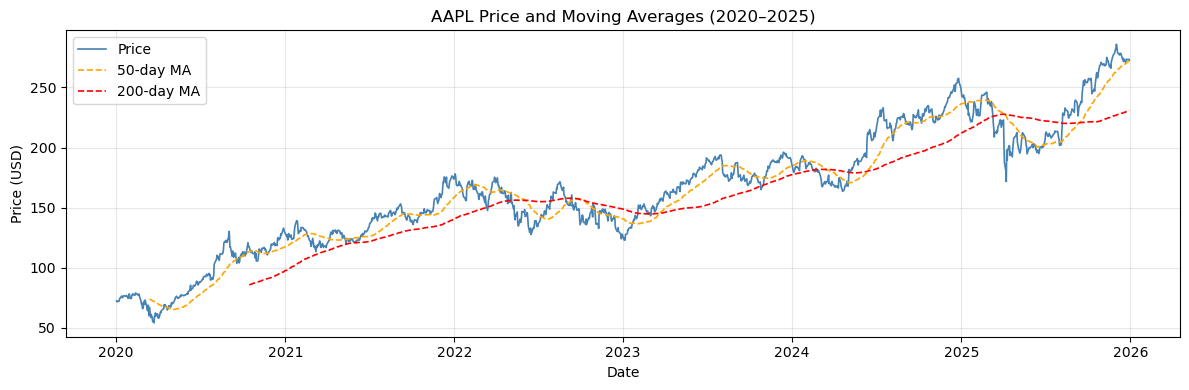

In [36]:
ticker = 'AAPL'

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(prices[ticker],  label='Price',    linewidth=1.2, color='steelblue')
ax.plot(ma_50[ticker],   label='50-day MA', linewidth=1.2, color='orange', linestyle='--')
ax.plot(ma_200[ticker],  label='200-day MA',linewidth=1.2, color='red',    linestyle='--')

ax.set_title('AAPL Price and Moving Averages (2020–2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/aapl_price_ma.png', dpi=150)
plt.show()

- **Return Distribution Histogram**

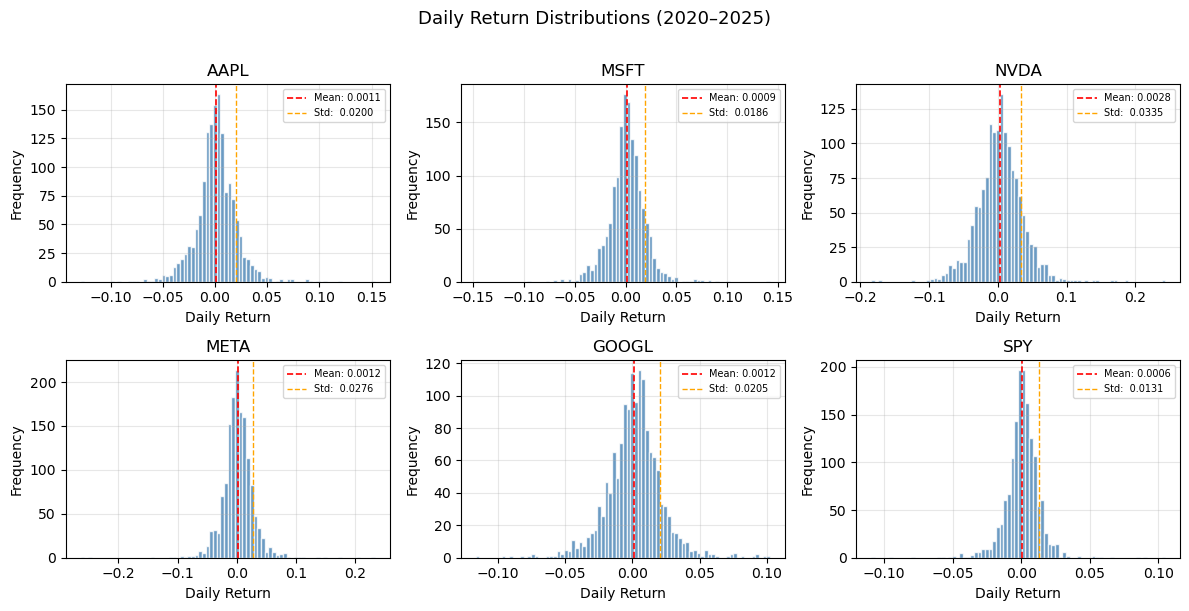

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    ax = axes[i]
    data = returns[ticker].dropna()
    
    ax.hist(data, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(data.mean(), color='red',    linestyle='--', linewidth=1.2, label=f'Mean: {data.mean():.4f}')
    ax.axvline(data.std(),  color='orange', linestyle='--', linewidth=1.0, label=f'Std:  {data.std():.4f}')
    
    ax.set_title(ticker)
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('Daily Return Distributions (2020–2025)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('charts/return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

- **Cumulative Reutrn (all stocks vs. SYP)**

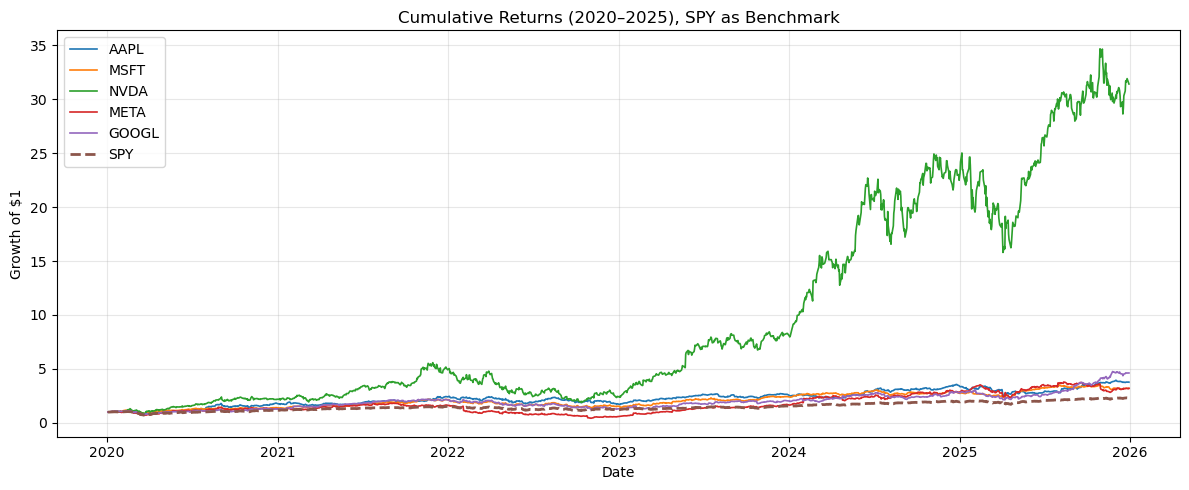

In [18]:
cumulative = (1 + returns).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))

for ticker in TICKERS:
    lw = 2.0 if ticker == 'SPY' else 1.2
    ls = '--' if ticker == 'SPY' else '-'
    ax.plot(cumulative[ticker], label=ticker, linewidth=lw, linestyle=ls)

ax.set_title('Cumulative Returns (2020–2025), SPY as Benchmark')
ax.set_xlabel('Date')
ax.set_ylabel('Growth of $1')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/cumulative_returns.png', dpi=150)
plt.show()

### **Key Observations**

- **Highest return:** NVDA at 78% annualized - more than 5x SPY's 15% return
- **Highest volatility:** NVDA at 53% - 2.6x the volatility of SPY (20%)- **Best Sharpe:** NVDA at 1.38, driven by outsized returns compensating for high risk
- **Most efficient (ex-NVDA):** GOOGL offers the best risk-adjusted return among 
  the remaining tickers (Sharpe 0.76) despite similar volatility to META
- **SPY benchmark:** Sharpe of 0.51 — most individual stocks failed to beat it 
  on a risk-adjusted basis; only NVDA and GOOGL exceeded it
- **META:** Highest volatility among non-NVDA stocks (44%) but lowest 
  risk-adjusted return — worst Sharpe of the group at 0.39